In [72]:
from pathlib import Path
import numpy as np
from pprint import pprint
from PIL import Image

from bovw import BagOfVisualWordsClassifier, BoVWConfig

In [73]:
def get(vocabulary_size, use_tfidf, method):
    dataset_root = Path('caltech101_reduced')
    feature_extractor = 'SIFT'

    config = BoVWConfig(
        feature_extractor=feature_extractor,
        vocabulary_size=vocabulary_size,
        max_descriptors_per_image=250,
        max_vocabulary_descriptors=20000,
        random_state=42,
    )
    model = BagOfVisualWordsClassifier(config)
    print('Training...')
    model.fit(dataset_root / 'train')
    print('Training finished.')

    test_images = sorted([p for p in (dataset_root / 'test').rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}])
    print(f'Found {len(test_images)} test images to index')

    print('Indexing... (this may take a while)')
    model.index_dataset(test_images, use_tfidf=use_tfidf)
    print('Index built. Indexed features shape:', getattr(model, '_index_features').shape)

    results = model.evaluate_retrieval(test_images, top_k=8, metric=method, use_tfidf=use_tfidf)
    print('Mean Precision@8: {:.4f}'.format(results['mean_precision_at_k']))
    print('Mean Recall@8: {:.4f}'.format(results['mean_recall_at_k']))
    print('Mean Average Precision (mAP): {:.4f}'.format(results['mean_average_precision']))

    result = {}

    result["mAP"] = results['mean_average_precision']
    result["recall"] = {}

    for el in results['per_query']:
        result["recall"][el["query"]] = el["recall_at_k"]
        print(f"{el["query"]}:{el["recall_at_k"]}")

    return result

In [74]:
resutls1 = get(100, True, "l2")

Training...
Training finished.
Found 46 test images to index
Indexing... (this may take a while)
Index built. Indexed features shape: (46, 100)
Mean Precision@8: 0.3397
Mean Recall@8: 0.3175
Mean Average Precision (mAP): 0.4088
caltech101_reduced\test\accordion\image_0010.jpg:0.5
caltech101_reduced\test\accordion\image_0012.jpg:0.7
caltech101_reduced\test\accordion\image_0017.jpg:0.2
caltech101_reduced\test\accordion\image_0020.jpg:0.5
caltech101_reduced\test\accordion\image_0021.jpg:0.6
caltech101_reduced\test\accordion\image_0024.jpg:0.2
caltech101_reduced\test\accordion\image_0031.jpg:0.6
caltech101_reduced\test\accordion\image_0036.jpg:0.5
caltech101_reduced\test\accordion\image_0050.jpg:0.3
caltech101_reduced\test\accordion\image_0051.jpg:0.5
caltech101_reduced\test\accordion\image_0054.jpg:0.4
caltech101_reduced\test\airplanes\image_0009.jpg:0.4444444444444444
caltech101_reduced\test\airplanes\image_0011.jpg:0.3333333333333333
caltech101_reduced\test\airplanes\image_0014.jpg:0.33

In [75]:
results2 = get(100, True, "cosine")

Training...
Training finished.
Found 46 test images to index
Indexing... (this may take a while)
Index built. Indexed features shape: (46, 100)
Mean Precision@8: 0.3397
Mean Recall@8: 0.3175
Mean Average Precision (mAP): 0.4088
caltech101_reduced\test\accordion\image_0010.jpg:0.5
caltech101_reduced\test\accordion\image_0012.jpg:0.7
caltech101_reduced\test\accordion\image_0017.jpg:0.2
caltech101_reduced\test\accordion\image_0020.jpg:0.5
caltech101_reduced\test\accordion\image_0021.jpg:0.6
caltech101_reduced\test\accordion\image_0024.jpg:0.2
caltech101_reduced\test\accordion\image_0031.jpg:0.6
caltech101_reduced\test\accordion\image_0036.jpg:0.5
caltech101_reduced\test\accordion\image_0050.jpg:0.3
caltech101_reduced\test\accordion\image_0051.jpg:0.5
caltech101_reduced\test\accordion\image_0054.jpg:0.4
caltech101_reduced\test\airplanes\image_0009.jpg:0.4444444444444444
caltech101_reduced\test\airplanes\image_0011.jpg:0.3333333333333333
caltech101_reduced\test\airplanes\image_0014.jpg:0.33

In [76]:
results3 = get(100, False, "cosine")

Training...
Training finished.
Found 46 test images to index
Indexing... (this may take a while)
Index built. Indexed features shape: (46, 100)
Mean Precision@8: 0.3370
Mean Recall@8: 0.3143
Mean Average Precision (mAP): 0.4020
caltech101_reduced\test\accordion\image_0010.jpg:0.5
caltech101_reduced\test\accordion\image_0012.jpg:0.7
caltech101_reduced\test\accordion\image_0017.jpg:0.3
caltech101_reduced\test\accordion\image_0020.jpg:0.3
caltech101_reduced\test\accordion\image_0021.jpg:0.6
caltech101_reduced\test\accordion\image_0024.jpg:0.2
caltech101_reduced\test\accordion\image_0031.jpg:0.6
caltech101_reduced\test\accordion\image_0036.jpg:0.4
caltech101_reduced\test\accordion\image_0050.jpg:0.3
caltech101_reduced\test\accordion\image_0051.jpg:0.5
caltech101_reduced\test\accordion\image_0054.jpg:0.5
caltech101_reduced\test\airplanes\image_0009.jpg:0.4444444444444444
caltech101_reduced\test\airplanes\image_0011.jpg:0.5555555555555556
caltech101_reduced\test\airplanes\image_0014.jpg:0.22

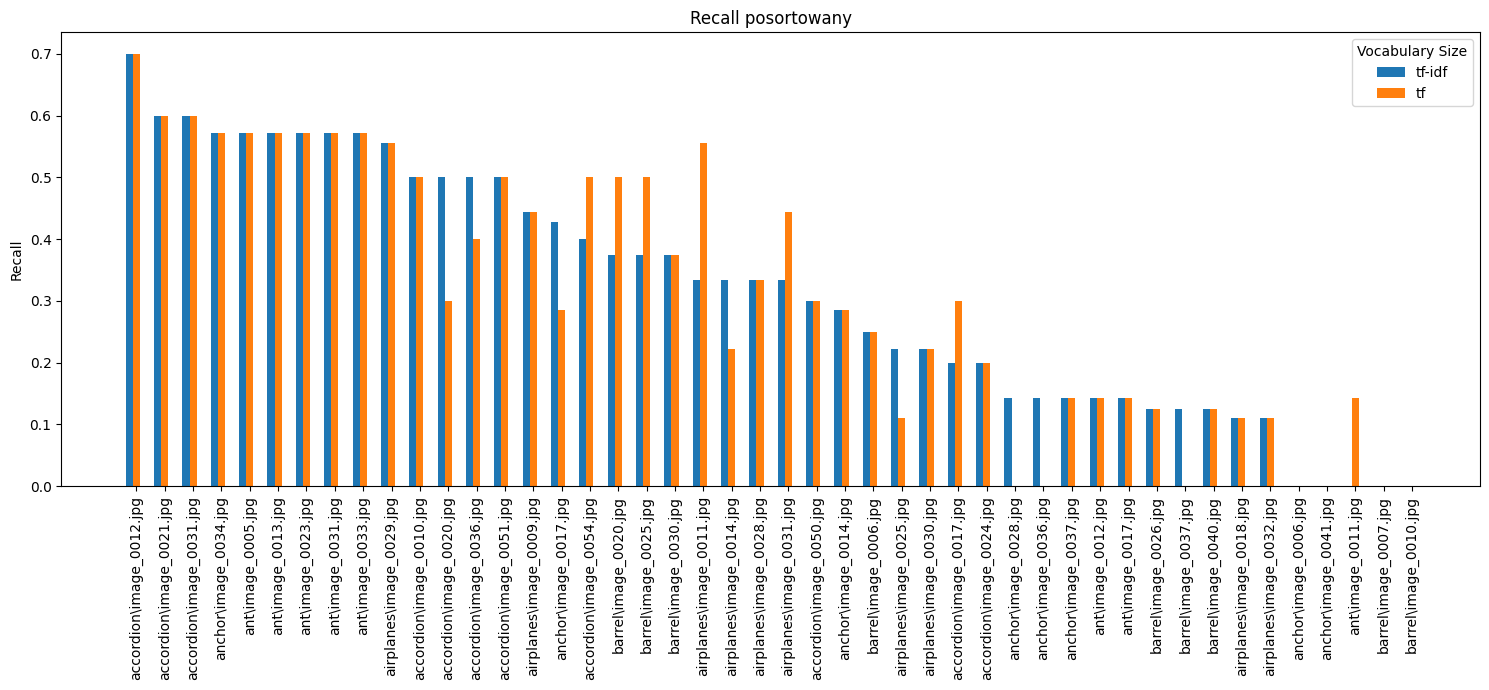

In [77]:
import matplotlib.pyplot as plt
import numpy as np

x_names_raw = list(results3["recall"].keys())

combined = []
for name in x_names_raw:
    combined.append((
        "\\".join(name.split("\\")[2:]), 
        results2["recall"][name], 
        results3["recall"][name]
    ))

combined.sort(key=lambda x: x[1], reverse=True)

x_names = [item[0] for item in combined]
vals_50k = [item[1] for item in combined]
vals_100k = [item[2] for item in combined]

x = np.arange(len(x_names))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 7))

ax.bar(x - width, vals_50k, width, label='tf-idf', color='#1f77b4')
ax.bar(x,         vals_100k, width, label='tf', color='#ff7f0e')

ax.set_ylabel('Recall')
ax.set_title('Recall posortowany')
ax.set_xticks(x)
ax.set_xticklabels(x_names, rotation=90)
ax.legend(title="Vocabulary Size")

plt.tight_layout()
plt.show()

In [78]:
dataset_root = Path('caltech101_reduced')
feature_extractor = 'SIFT'

config = BoVWConfig(
    feature_extractor=feature_extractor,
    vocabulary_size=100,
    max_descriptors_per_image=250,
    max_vocabulary_descriptors=20000,
    random_state=42,
)
model = BagOfVisualWordsClassifier(config)
model.fit(dataset_root / 'train')

test_images = sorted([p for p in (dataset_root / 'test').rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}])
print(f'Found {len(test_images)} test images to index')

print('Indexing... (this may take a while)')
model.index_dataset(test_images, use_tfidf=False)
print('Index built. Indexed features shape:', getattr(model, '_index_features').shape)

Found 46 test images to index
Indexing... (this may take a while)
Index built. Indexed features shape: (46, 100)


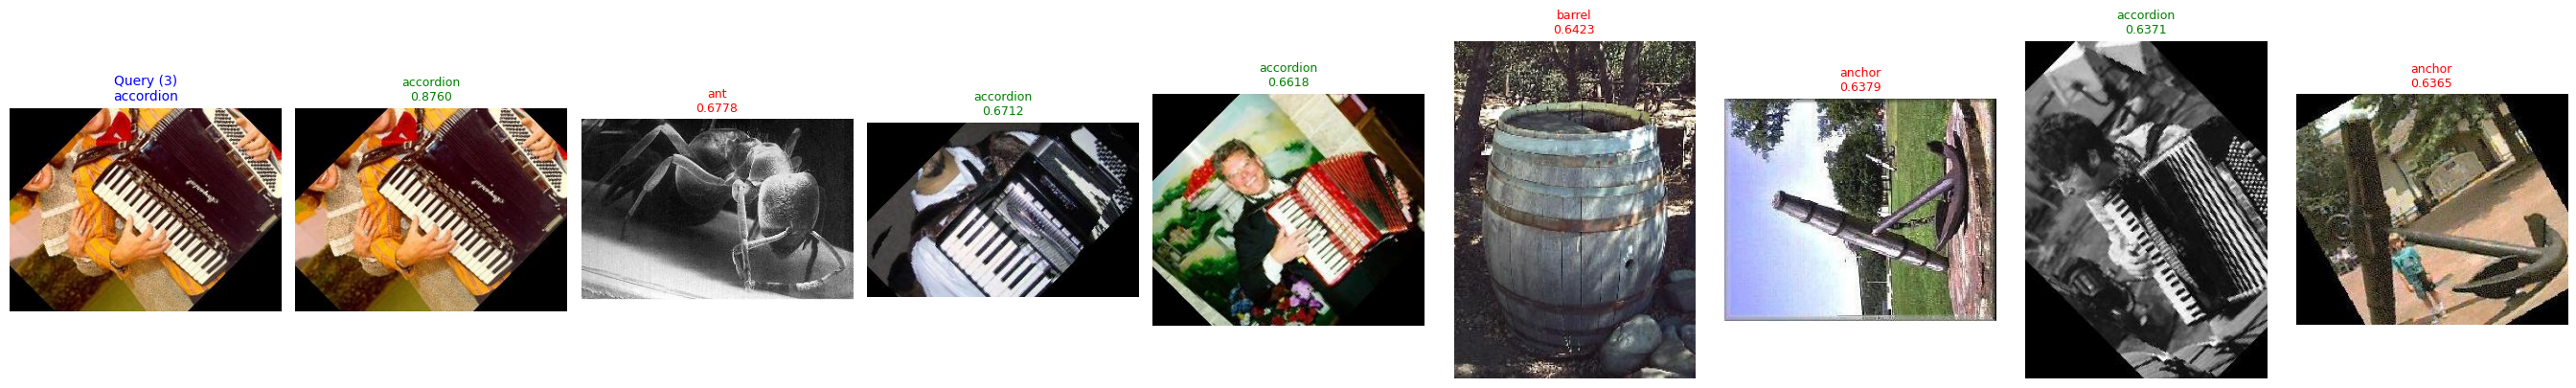

In [79]:
query_idx = 3
query_path = test_images[query_idx]
    
results = model.query(query_path, top_k=8, metric='cosine', use_tfidf=False)

n = len(results) + 1
fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))

qimg = Image.open(query_path).convert('RGB')
axes[0].imshow(qimg)
axes[0].set_title(f'Query ({query_idx})\n{query_path.parent.name}', fontsize=10, color='blue')
axes[0].axis('off')

for i, (p, score) in enumerate(results, start=1):
    img = Image.open(p).convert('RGB')
    axes[i].imshow(img)
    
    is_correct = p.parent.name == query_path.parent.name
    title_color = 'green' if is_correct else 'red'
    
    axes[i].set_title(f'{p.parent.name}\n{score:.4f}', fontsize=9, color=title_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Bez ważenia histogramu algorytm dla powyższego przypadku skupił się na kontraście (czerń vs biel). Dla niektórych przypadków wynik zmalał, bo unikalne cechy obiektu zostały zbyt mocno stłumione. Jednak ogólnie zwiększył dokładność